1. Setup

In [ ]:
!pip install -q -U transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 10.3 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import pandas as pd
import torch

def set_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
MODEL_NAME   = "distilbert-base-uncased"
DATASET_ID   = "GonzaloA/fake_news"
TEXT_COLUMN  = "text"
LABEL_COLUMN = "label"
LABEL_NAMES  = ["Fake", "Real"]
MAX_LENGTH   = 256
TRAIN_SAMPLES = 8000
TEST_SAMPLES  = 2000
BATCH_SIZE    = 16
EPOCHS        = 3
LEARNING_RATE = 2e-5
SEED          = 42

set_seed(SEED)

2. Load Dataset

In [ ]:
from datasets import load_dataset

raw = load_dataset("GonzaloA/fake_news")
print(raw)

first = list(raw.keys())[0]
print("\nColumns:", raw[first].column_names)
ex = raw[first][0]
print("\nExample label:", ex.get(LABEL_COLUMN))
print("Example text (first 300 chars):\n", str(ex.get(TEXT_COLUMN))[:300])

README.md:   0%|          | 0.00/6.73k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 38.8MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 24353
    })
    validation: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
    test: Dataset({
        features: ['Unnamed: 0', 'title', 'text', 'label'],
        num_rows: 8117
    })
})

Columns: ['Unnamed: 0', 'title', 'text', 'label']

Example label: 0
Example text (first 300 chars):
 Maury is perhaps one of the trashiest shows on television today. It s right in line with the likes of the gutter trash that is Jerry Springer, and the fact that those shows are still on the air with the shit they air really is a sad testament to what Americans find to be entertaining. However, Maury


In [ ]:
_check = raw[first].to_pandas()
for lbl in sorted(_check[LABEL_COLUMN].unique()):
    print(f"\n===== label {lbl}  ->  LABEL_NAMES[{lbl}] = '{LABEL_NAMES[lbl]}' =====")
    for txt in _check[_check[LABEL_COLUMN] == lbl][TEXT_COLUMN].head(2):
        print("   -", str(txt)[:150].replace(chr(10), ' '), "...")


===== label 0  ->  LABEL_NAMES[0] = 'Fake' =====
   - Maury is perhaps one of the trashiest shows on television today. It s right in line with the likes of the gutter trash that is Jerry Springer, and the ...
   - Yesterday, after the father of one of the UCLA players arrested in China failed to show Trump proper gratitude for getting his kid released, Trump, pr ...

===== label 1  ->  LABEL_NAMES[1] = 'Real' =====
   - MOSCOW (Reuters) - Russia on Wednesday warned Iraq and the Kurds against taking any steps that might destabilize the Middle East after a Kurdish indep ...
   - LONDON (Reuters) - The lead Brexit negotiator for the European Parliament poked fun at British Prime Minister Theresa May on Thursday, quipping that s ...


3. Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

df = pd.concat([raw[s].to_pandas() for s in raw.keys()], ignore_index=True)
df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna()
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df[LABEL_COLUMN], random_state=SEED
)
train_df = train_df.sample(n=min(TRAIN_SAMPLES, len(train_df)), random_state=SEED).reset_index(drop=True)
test_df  = test_df.sample(n=min(TEST_SAMPLES,  len(test_df)),  random_state=SEED).reset_index(drop=True)

y_train = train_df[LABEL_COLUMN].values
y_test  = test_df[LABEL_COLUMN].values
print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print(train_df[LABEL_COLUMN].value_counts(normalize=True).rename(index=dict(enumerate(LABEL_NAMES))))

Train: 8000 | Test: 2000
label
Real    0.54425
Fake    0.45575
Name: proportion, dtype: float64


4. Baseline models- TF-IDF + Logistic Regression/Navie Bayes

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")
X_train = tfidf.fit_transform(train_df[TEXT_COLUMN])   # fit on train only (no leakage)
X_test  = tfidf.transform(test_df[TEXT_COLUMN])

logreg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
base_preds = logreg.predict(X_test)
print("=== TF-IDF + Logistic Regression ===")
print(classification_report(y_test, base_preds, target_names=LABEL_NAMES, digits=4))

nb = MultinomialNB().fit(X_train, y_train)
nb_preds = nb.predict(X_test)
print("=== TF-IDF + Multinomial Naive Bayes ===")
print(classification_report(y_test, nb_preds, target_names=LABEL_NAMES, digits=4))

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

        Fake     0.9670    0.9544    0.9607       921
        Real     0.9615    0.9722    0.9668      1079

    accuracy                         0.9640      2000
   macro avg     0.9642    0.9633    0.9637      2000
weighted avg     0.9640    0.9640    0.9640      2000

=== TF-IDF + Multinomial Naive Bayes ===
              precision    recall  f1-score   support

        Fake     0.9292    0.9262    0.9277       921
        Real     0.9372    0.9398    0.9385      1079

    accuracy                         0.9335      2000
   macro avg     0.9332    0.9330    0.9331      2000
weighted avg     0.9335    0.9335    0.9335      2000



5.Preprocess for BERT

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

demo = tokenizer("Scientists confirm the earth is round.", truncation=True, max_length=MAX_LENGTH)
print("Keys:", list(demo.keys()))
print("First 12 ids:", demo["input_ids"][:12])
print("Decoded:", tokenizer.decode(demo["input_ids"]))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Keys: ['input_ids', 'token_type_ids', 'attention_mask']
First 12 ids: [101, 6529, 12210, 1996, 3011, 2003, 2461, 1012, 102]
Decoded: [CLS] scientists confirm the earth is round. [SEP]


Wrap tokenized data in PyTorch

In [ ]:
from torch.utils.data import Dataset, DataLoader

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(list(texts), truncation=True, padding="max_length",
                                   max_length=max_length, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_ds = NewsDataset(train_df[TEXT_COLUMN], y_train, tokenizer, MAX_LENGTH)
test_ds  = NewsDataset(test_df[TEXT_COLUMN],  y_test,  tokenizer, MAX_LENGTH)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print("Batches per epoch:", len(train_loader))

Batches per epoch: 500


6.No Fine-tuning baseline

In [ ]:
from transformers import AutoModel

feature_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
feature_model.eval()

def embed(texts):
    """Return the [CLS] embedding for each text from the frozen pre-trained model."""
    vecs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = tokenizer(texts[i:i+BATCH_SIZE], truncation=True, padding=True,
                              max_length=MAX_LENGTH, return_tensors="pt").to(device)
            cls = feature_model(**batch).last_hidden_state[:, 0]  # [CLS] token = index 0
            vecs.append(cls.cpu().numpy())
    return np.vstack(vecs)

emb_train = embed(train_df[TEXT_COLUMN].tolist())
emb_test  = embed(test_df[TEXT_COLUMN].tolist())

frozen_clf = LogisticRegression(max_iter=1000).fit(emb_train, y_train)
frozen_preds = frozen_clf.predict(emb_test)
print("=== Frozen pre-trained DistilBERT features + LogReg (NO fine-tuning) ===")
print(classification_report(y_test, frozen_preds, target_names=LABEL_NAMES, digits=4))
del feature_model
torch.cuda.empty_cache()

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Frozen pre-trained DistilBERT features + LogReg (NO fine-tuning) ===
              precision    recall  f1-score   support

        Fake     0.9749    0.9707    0.9728       921
        Real     0.9751    0.9787    0.9769      1079

    accuracy                         0.9750      2000
   macro avg     0.9750    0.9747    0.9748      2000
weighted avg     0.9750    0.9750    0.9750      2000



7. Fine-tune DistilBERT

In [ ]:
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score
import torch.nn as nn

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()
num_training_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(optimizer, 0, num_training_steps)

def evaluate(model, loader):
    """Run the model over a loader and return (accuracy, predictions, true_labels)."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            labels.extend(batch["labels"].numpy())
    return accuracy_score(labels, preds), preds, labels

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from tqdm.auto import tqdm

history = {"epoch": [0], "train_loss": [None], "test_acc": []
acc0, _, _ = evaluate(model, test_loader)
history["test_acc"].append(acc0)
print(f"Epoch 0 (before fine-tuning) test accuracy: {acc0:.4f}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    progress = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for batch in progress:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        running += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    avg = running / len(train_loader)
    acc, _, _ = evaluate(model, test_loader)
    history["epoch"].append(epoch); history["train_loss"].append(avg); history["test_acc"].append(acc)
    print(f"Epoch {epoch}: train_loss={avg:.4f}  test_acc={acc:.4f}")

Epoch 0 (before fine-tuning) test accuracy: 0.5130


Epoch 1/3:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1: train_loss=0.0742  test_acc=0.9830


Epoch 2/3:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2: train_loss=0.0306  test_acc=0.9870


Epoch 3/3:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 3: train_loss=0.0129  test_acc=0.9885


Learning-curve figure

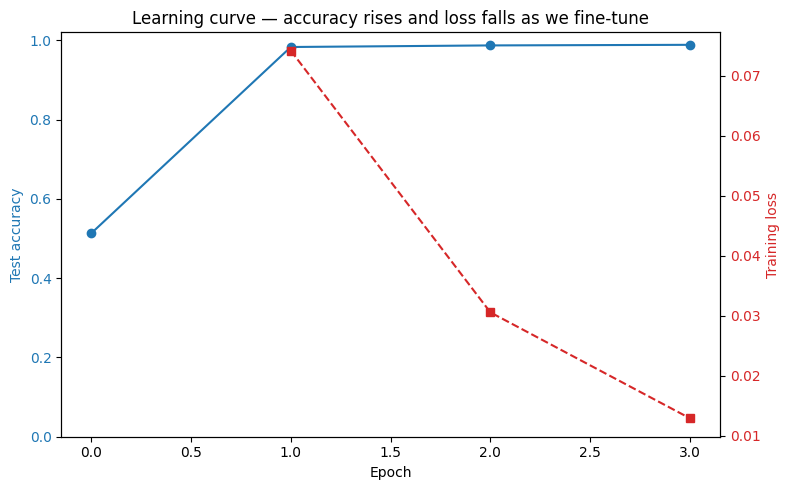

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))
ep = history["epoch"]
ax1.plot(ep, history["test_acc"], "o-", color="tab:blue", label="Test accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Test accuracy", color="tab:blue")
ax1.set_ylim(0, 1.02); ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(ep[1:], history["train_loss"][1:], "s--", color="tab:red", label="Train loss")
ax2.set_ylabel("Training loss", color="tab:red"); ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Learning curve — accuracy rises and loss falls as we fine-tune")
fig.tight_layout(); plt.show()

8. Evaluate the fine-tuned model

In [ ]:
_, bert_preds, true_labels = evaluate(model, test_loader)
print("=== DistilBERT (fine-tuned) ===")
print(classification_report(true_labels, bert_preds, target_names=LABEL_NAMES, digits=4))

=== DistilBERT (fine-tuned) ===
              precision    recall  f1-score   support

        Fake     0.9880    0.9870    0.9875       921
        Real     0.9889    0.9898    0.9893      1079

    accuracy                         0.9885      2000
   macro avg     0.9885    0.9884    0.9884      2000
weighted avg     0.9885    0.9885    0.9885      2000



Confusion matrix

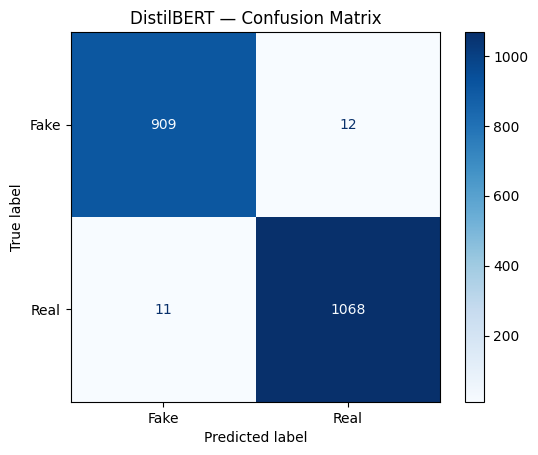

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(true_labels, bert_preds, display_labels=LABEL_NAMES, cmap="Blues")
plt.title("DistilBERT — Confusion Matrix"); plt.show()

9. Final Comparison

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

def score(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return [acc, p, r, f]

results = pd.DataFrame(
    [
        ["TF-IDF + LogReg",                 *score(y_test, base_preds)],
        ["TF-IDF + Naive Bayes",            *score(y_test, nb_preds)],
        ["Frozen BERT feats + LogReg (no FT)", *score(y_test, frozen_preds)],
        ["DistilBERT (fine-tuned)",         *score(true_labels, bert_preds)],
    ],
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"],
)
results.set_index("Model").round(4)

,Accuracy,Precision,Recall,F1
Model,,,,
TF-IDF + LogReg,0.9640,0.9642,0.9633,0.9637
TF-IDF + Naive Bayes,0.9335,0.9332,0.9330,0.9331
Frozen BERT feats + LogReg (no FT),0.9750,0.9750,0.9747,0.9748
DistilBERT (fine-tuned),0.9885,0.9885,0.9884,0.9884


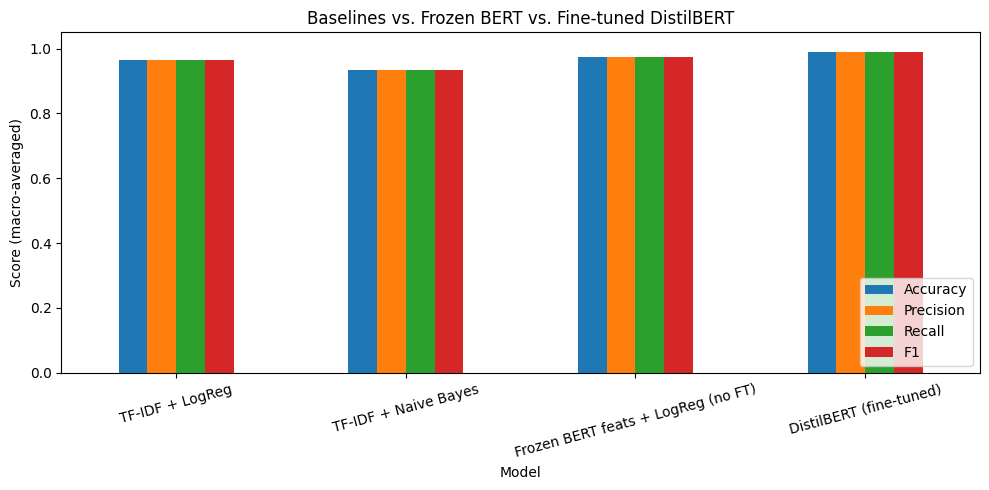

In [ ]:
ax = results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(10, 5), rot=15, ylim=(0, 1.05))
ax.set_title("Baselines vs. Frozen BERT vs. Fine-tuned DistilBERT")
ax.set_ylabel("Score (macro-averaged)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

10. Save the fine-tune model

In [ ]:
save_dir = "distilbert-fake-news"
model.save_pretrained(save_dir); tokenizer.save_pretrained(save_dir)
print("Saved to:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: distilbert-fake-news
